[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter10_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 10: Market Microstructure

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook computes the charts and tables of Chapter 10: a simulated order book, spread and illiquidity measures on real data, intraday patterns, Glosten–Milgrom and Kyle, price impact, optimal execution and two stress episodes.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
GROUP_COL = {'US': MainBlue, 'BVB': IDAred, 'Crypto': Amber}

HERE = '.'
SEED = 42
START2 = '2024-09-19'
START10 = '2016-09-19'
B_BOOT = 1000



def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """A single legend for a multi-panel figure, below the figure."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## Data

- SPY 5-minute bars, regular session (09:30–16:00 New York time), October 2020 – September 2026; Bitcoin 5-minute bars (UTC), September 2024 – September 2026.
- Daily open, high, low, close and volume for US stocks, Bucharest Stock Exchange (BVB) stocks and crypto-assets; prices adjusted for dividends and splits.
- BVB traded values converted from lei to USD at the reference rate of the National Bank of Romania (BNR); crypto traded values are in USD.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# use the local copy of the course data when the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# key -> (symbol, label, group)
ASSETS = {
    'SPY': ('SPY.US', 'SPY', 'US'), 'AAPL': ('AAPL.US', 'Apple', 'US'), 'MSFT': ('MSFT.US', 'Microsoft', 'US'),
    'NVDA': ('NVDA.US', 'NVIDIA', 'US'), 'JPM': ('JPM.US', 'JPMorgan', 'US'), 'GME': ('GME.US', 'GameStop', 'US'),
    'MSTR': ('MSTR.US', 'Strategy', 'US'),
    'TLV': ('TLV.RO', 'Banca Transilvania', 'BVB'), 'SNP': ('SNP.RO', 'OMV Petrom', 'BVB'),
    'H2O': ('H2O.RO', 'Hidroelectrica', 'BVB'), 'BRD': ('BRD.RO', 'BRD', 'BVB'), 'SNG': ('SNG.RO', 'Romgaz', 'BVB'),
    'SNN': ('SNN.RO', 'Nuclearelectrica', 'BVB'), 'TGN': ('TGN.RO', 'Transgaz', 'BVB'),
    'EL': ('EL.RO', 'Electrica', 'BVB'), 'DIGI': ('DIGI.RO', 'Digi', 'BVB'), 'TEL': ('TEL.RO', 'Transelectrica', 'BVB'),
    'TVBETETF': ('TVBETETF.RO', 'BET ETF', 'BVB'),
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'Crypto'), 'ETH': ('ETH-USD.CC', 'Ethereum', 'Crypto'),
    'SOL': ('SOL-USD.CC', 'Solana', 'Crypto'), 'XRP': ('XRP-USD.CC', 'XRP', 'Crypto'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'Crypto'), 'ADA': ('ADA-USD.CC', 'Cardano', 'Crypto'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'Crypto'),
}
GROUPS = {g: [k for k, v in ASSETS.items() if v[2] == g] for g in ('US', 'BVB', 'Crypto')}
LABELS = {k: v[1] for k, v in ASSETS.items()}
# large adjustment events that are cash dividends, not splits (issuer announcement):
#   SNN.RO 2018-12-21: gross dividend of 1.61 lei per share, ex-date 21 December 2018
#   (https://www.nuclearelectrica.ro/wp-content/uploads/2018/12/SNN_Comunicat-plata-dividende-suplimentare_EN.pdf)
CASH_DIVIDENDS = {'SNN.RO': ['2018-12-21']}

_CACHE = {}


def read_market(symbol):
    """Read the daily price file of one symbol, from a local copy or from the GitHub repository."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def read_reference_rate(currency='USD', start='2014-01-01', end=END):
    """Official RON reference rate (BNR yearly XML archives)."""
    key = ('REF', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'rate']).drop_duplicates('date').set_index('date')['rate']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def _clean(key, d):
    d = d[(d['high'] > d['low']) & (d['volume'].fillna(0) > 0)]
    if ASSETS[key][2] != 'Crypto':
        d = d[d.index.dayofweek < 5]
        # isolated bad ticks: adjusted price more than twice / less than half the local median (21 days)
        med = d['adjusted_close'].rolling(21, center=True, min_periods=5).median()
        d = d[np.abs(np.log(d['adjusted_close'] / med)) < np.log(2)]
    return d


def ohlc(key, start='2016-09-19', end=END):
    """Open, high, low, close scaled by the adjustment factor of the adjusted price (dividends and splits)."""
    d = read_market(ASSETS[key][0]).loc[start:end].copy()
    f = d['adjusted_close'] / d['close']
    for c in ['open', 'high', 'low', 'close']:
        d[c] = d[c] * f
    return _clean(key, d)[['open', 'high', 'low', 'close', 'volume']]


def split_adjusted_close(d, symbol=None):
    """Close price adjusted ONLY for splits and bonus shares (same basis as the volume in number of shares);
    the large cash dividends in CASH_DIVIDENDS are not treated as splits."""
    k = (d['close'].shift(1) / d['close']) / (d['adjusted_close'].shift(1) / d['adjusted_close'])
    k = k.where(np.abs(np.log(k)) > 0.15, 1.0).fillna(1.0)      # split days: the split ratio
    for day in CASH_DIVIDENDS.get(symbol, []):
        k.loc[k.index == pd.Timestamp(day)] = 1.0
    back = k[::-1].cumprod()[::-1].shift(-1).fillna(1.0)          # product of the splits after each day
    return d['close'] / back


def returns(key, start='2016-09-19', end=END):
    """Daily log returns from the adjusted price (days without trading dropped)."""
    d = read_market(ASSETS[key][0]).loc[start:end]
    d = _clean(key, d)
    return np.log(d['adjusted_close']).diff().dropna().rename(key)


def dollar_volume(key, start='2016-09-19', end=END):
    """Daily traded value, in USD."""
    d = read_market(ASSETS[key][0]).loc[:end]
    grp = ASSETS[key][2]
    if grp == 'Crypto':
        dv = d['volume']                                          # already in USD
    else:
        dv = split_adjusted_close(d, ASSETS[key][0]) * d['volume']
        if grp == 'BVB':                                          # RON -> USD at the BNR reference rate
            fx = read_reference_rate('USD', start='2014-01-01', end=end)
            dv = dv / fx.reindex(dv.index).ffill()
    d = _clean(key, d.assign(dv=dv))
    return d['dv'].loc[start:end].dropna().rename(key)


def intraday_spy():
    """SPY 5-minute bars, regular session (09:30-15:55 = bar start), complete days only (78 bars)."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    t = d['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None)
    d = d.assign(t=t, date=t.dt.normalize(), tod=t.dt.strftime('%H:%M')).drop(columns='datetime_utc')
    d = d[(d['tod'] >= '09:30') & (d['tod'] <= '15:55')]
    n = d.groupby('date').size()
    d = d[d['date'].isin(n[n == 78].index)].set_index('t').sort_index()
    d['r'] = np.log(d['close']).groupby(d['date']).diff()
    first = d['tod'] == '09:30'
    d.loc[first, 'r'] = np.log(d.loc[first, 'close'] / d.loc[first, 'open'])   # first bar: from the open
    d['dv'] = d['close'] * d['volume']
    return d


def intraday_btc():
    """Bitcoin 5-minute bars (UTC), 24 hours a day; volume is not used (missing on many bars)."""
    fname = 'intraday/BTC-USD.CC_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d = d.set_index('datetime_utc').sort_index()
    d = d[~d.index.duplicated()]
    d['date'] = d.index.normalize()
    d['r'] = np.log(d['close']).diff()
    gap = d.index.to_series().diff() != pd.Timedelta('5min')
    d.loc[gap, 'r'] = np.nan                                       # no returns across missing bars
    return d

## Estimators and models

- `roll_spread`, `cs_spread`, `ar_terms`, `edge_spread`, `amihud`: spread and illiquidity measures; `roll_mc`: Monte Carlo of the Roll model.
- `price_discovery`: information shares from a vector error-correction model (VECM); `pin_loglik`: the likelihood of the probability of informed trading (PIN) in stable form.
- `walk_book`, `zi_simulate`: order book execution and a simulated order book.
- `gm_quotes`, `gm_simulate`, `kyle`, `ac_trajectory`, `ac_frontier`: Glosten–Milgrom, Kyle and Almgren–Chriss.

In [4]:
def roll_spread(close):
    """Roll relative spread from the first-order autocovariance of log returns; NaN if the covariance is positive."""
    r = np.log(np.asarray(close, float))
    dp = np.diff(r)
    c = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return (2 * np.sqrt(-c) if c < 0 else np.nan), c


def cs_spread(high, low, close=None):
    """Corwin-Schultz estimator for each pair of consecutive periods (negative values set to 0).
    With close (daily data): the overnight adjustment of Corwin and Schultz (2012): if the low of day t+1 is above
    the close of day t, the high and low of t+1 are lowered by the difference; if the high of t+1 is below the close
    of t, both are raised by the difference. Intraday bars of the same session are not adjusted."""
    H, L = np.asarray(high, float), np.asarray(low, float)
    h0, l0, h1, l1 = H[:-1], L[:-1], H[1:].copy(), L[1:].copy()
    if close is not None:
        c0 = np.asarray(close, float)[:-1]
        up = l1 > c0
        d = np.where(up, l1 - c0, 0.0)
        h1, l1 = h1 - d, l1 - d
        dn = h1 < c0
        d = np.where(dn, c0 - h1, 0.0)
        h1, l1 = h1 + d, l1 + d
    beta = np.log(h0 / l0) ** 2 + np.log(h1 / l1) ** 2
    gamma = np.log(np.maximum(h0, h1) / np.minimum(l0, l1)) ** 2
    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    return np.clip(2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha)), 0, None)


def ar_terms(close, high, low):
    """Abdi-Ranaldo terms: 4 (c_t - eta_t)(c_t - eta_{t+1}); their mean estimates s^2."""
    c = np.log(np.asarray(close, float))
    eta = (np.log(np.asarray(high, float)) + np.log(np.asarray(low, float))) / 2
    return 4 * (c[:-1] - eta[:-1]) * (c[:-1] - eta[1:])


def ar_spread(close, high, low):
    """Abdi-Ranaldo relative spread: sqrt(max(mean of the terms, 0))."""
    m = np.mean(ar_terms(close, high, low))
    return np.sqrt(max(m, 0.0)), m


def edge_spread(open_, high, low, close, sign=True):
    """EDGE (Ardia, Guidotti and Kroencke, 2024, JFE 161, 103916): relative spread from OHLC prices.
    Follows the authors' reference implementation (bidask package, MIT licence). sign=True returns the signed
    estimate; for averages over several windows, each negative window estimate is set to zero before averaging."""
    o, h, l, c = (np.log(np.asarray(x, float)) for x in (open_, high, low, close))
    if len(o) < 3:
        return np.nan
    m = (h + l) / 2.
    h1, l1, c1, m1 = h[:-1], l[:-1], c[:-1], m[:-1]
    o, h, l, c, m = o[1:], h[1:], l[1:], c[1:], m[1:]
    r1, r2, r3, r4, r5 = m - o, o - m1, m - c1, c1 - m1, o - c1
    tau = np.where(np.isnan(h) | np.isnan(l) | np.isnan(c1), np.nan, (h != l) | (l != c1))
    po1 = tau * np.where(np.isnan(o) | np.isnan(h), np.nan, o != h)
    po2 = tau * np.where(np.isnan(o) | np.isnan(l), np.nan, o != l)
    pc1 = tau * np.where(np.isnan(c1) | np.isnan(h1), np.nan, c1 != h1)
    pc2 = tau * np.where(np.isnan(c1) | np.isnan(l1), np.nan, c1 != l1)
    pt = np.nanmean(tau)
    po = np.nanmean(po1) + np.nanmean(po2)
    pc = np.nanmean(pc1) + np.nanmean(pc2)
    if np.nansum(tau) < 2 or po == 0 or pc == 0:
        return np.nan
    d1 = r1 - np.nanmean(r1) / pt * tau
    d3 = r3 - np.nanmean(r3) / pt * tau
    d5 = r5 - np.nanmean(r5) / pt * tau
    x1 = -4. / po * d1 * r2 - 4. / pc * d3 * r4
    x2 = -4. / po * d1 * r5 - 4. / pc * d5 * r4
    e1, e2 = np.nanmean(x1), np.nanmean(x2)
    v1, v2 = np.nanmean(x1 ** 2) - e1 ** 2, np.nanmean(x2 ** 2) - e2 ** 2
    vt = v1 + v2
    s2 = (v2 * e1 + v1 * e2) / vt if vt > 0 else (e1 + e2) / 2.
    s = np.sqrt(np.abs(s2))
    return float(s * np.sign(s2)) if sign else float(s)


def amihud(r, dv, scale=1e6):
    """Amihud illiquidity: mean |r| (basis points) per USD 1 million traded."""
    x = pd.concat([r.rename('r'), dv.rename('dv')], axis=1, join='inner').dropna()
    x = x[x['dv'] > 0]
    return float((1e4 * x['r'].abs() / (x['dv'] / scale)).mean())


def daily_estimates(d, overnight=True):
    """Spread estimators over a window of bars: overnight=True for daily data (Corwin-Schultz overnight
    adjustment), overnight=False for the intraday bars of one session."""
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'], d['close'] if overnight else None)
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return pd.Series(dict(cov=cov, roll=rs, cs=cs.mean(), ar2=ar2.mean()))


def roll_mc(c, sigma, T=78, R=20000, seed=42):
    """Harris (1990): simulate the Roll model (m_t a random walk with N(0, sigma^2) steps, q_t = +-1 with prob. 1/2)
    over T prices and compute the first-order autocovariance of the (demeaned) changes, as on real data."""
    rng = np.random.default_rng(seed)
    p = np.cumsum(rng.normal(0, sigma, (R, T)), axis=1) + c * np.where(rng.random((R, T)) < 0.5, 1, -1)
    dp = np.diff(p, axis=1)
    dm = dp - dp.mean(axis=1, keepdims=True)
    return (dm[:, 1:] * dm[:, :-1]).mean(axis=1)


def price_discovery(y, p=1):
    """Bivariate VECM with the cointegrating vector (1, -1) imposed: dy_t = a0 + alpha (y1 - y2)_{t-1} + sum Gamma_i dy_{t-i} + e_t.
    Returns alpha, the t statistics, the Gonzalo-Granger component share (normalised alpha_perp) and the bounds
    of the Hasbrouck information share (the two Cholesky orderings)."""
    y = np.asarray(y, float)
    dy = np.diff(y, axis=0)
    z = (y[:, 0] - y[:, 1])[:-1]
    X = np.array([[1.0, z[t]] + [v for i in range(1, p + 1) for v in dy[t - i]] for t in range(p, len(dy))])
    Y = dy[p:]
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    U = Y - X @ B
    Om = U.T @ U / (len(U) - X.shape[1])
    alpha = B[1]
    se = np.sqrt(np.linalg.inv(X.T @ X)[1, 1] * np.diag(Om))
    ap = np.array([-alpha[1], alpha[0]])                       # alpha_perp: alpha' alpha_perp = 0
    cs = ap / ap.sum()
    psi = ap                                                    # common row of the long-run impact matrix (up to scale)
    IS = []
    for order in ([0, 1], [1, 0]):
        F = np.linalg.cholesky(Om[np.ix_(order, order)])
        v = (psi[order] @ F) ** 2 / (psi @ Om @ psi)
        IS.append(v[np.argsort(order)])
    IS = np.array(IS)
    return dict(alpha=alpha, t=alpha / se, cs=cs, is_lo=IS.min(axis=0), is_hi=IS.max(axis=0),
                corr=float(Om[0, 1] / np.sqrt(Om[0, 0] * Om[1, 1])), resid=U, n=len(U))


def pin_loglik(B, S, alpha, delta, mu, eb, es):
    """EKOP log-likelihood of a day with B buys and S sells, in the factorised form that avoids
    numerical overflow (Lin and Ke, 2011): ln L = -eb - es + B ln(mu + eb) + S ln(mu + es) - ln B! - ln S!
    + ln[(1 - alpha) xb^B xs^S + alpha delta e^-mu xb^B + alpha (1 - delta) e^-mu xs^S], xb = eb / (mu + eb)."""
    from scipy.special import gammaln, logsumexp
    lxb, lxs = np.log(eb / (mu + eb)), np.log(es / (mu + es))
    terms = [np.log(1 - alpha) + B * lxb + S * lxs, np.log(alpha * delta) - mu + B * lxb,
             np.log(alpha * (1 - delta)) - mu + S * lxs]
    base = -eb - es + B * np.log(mu + eb) + S * np.log(mu + es) - gammaln(B + 1) - gammaln(S + 1)
    return float(base + logsumexp(terms)), terms


def walk_book(asks, qty):
    """Market buy order of size qty against the sell offers asks = [(price, quantity), ...] in ascending order.
    Returns the fills, the volume-weighted average price and the remaining offers."""
    fills, left, rest = [], qty, []
    for p, q in asks:
        if left <= 0:
            rest.append((p, q))
            continue
        take = min(q, left)
        fills.append((p, take))
        left -= take
        if q > take:
            rest.append((p, q - take))
    vwap = sum(p * q for p, q in fills) / sum(q for _, q in fills)
    return fills, vwap, rest, left


def gm_quotes(theta, mu, vl, vh):
    """Ask and bid quotes: expected value conditional on a buy and on a sell, respectively.
    theta = P(V = vh), mu = share of informed traders; uninformed traders buy or sell with prob. 1/2."""
    pb_h, pb_l = mu + (1 - mu) / 2, (1 - mu) / 2               # P(buy | V = vh), P(buy | V = vl)
    th_b = pb_h * theta / (pb_h * theta + pb_l * (1 - theta))   # P(V = vh | buy)
    th_s = pb_l * theta / (pb_l * theta + pb_h * (1 - theta))   # P(V = vh | sell)
    return vl + th_b * (vh - vl), vl + th_s * (vh - vl), th_b, th_s


def gm_simulate(mu, vl=90.0, vh=110.0, v=110.0, n=60, seed=1):
    """A sequence of trades when the true value is v; the market maker learns from the order flow."""
    rng = np.random.default_rng(seed)
    theta, rows = 0.5, []
    for t in range(n):
        ask, bid, th_b, th_s = gm_quotes(theta, mu, vl, vh)
        informed = rng.random() < mu
        buy = (v == vh) if informed else (rng.random() < 0.5)
        rows.append(dict(t=t, ask=ask, bid=bid, theta=theta, buy=buy))
        theta = th_b if buy else th_s
    return pd.DataFrame(rows)


def kyle(sigma_v, sigma_u):
    """Kyle equilibrium: v ~ N(p0, sigma_v^2), noise-trader demand u ~ N(0, sigma_u^2).
    Informed strategy x = beta (v - p0), price p = p0 + lambda (x + u)."""
    beta = sigma_u / sigma_v
    lam = sigma_v / (2 * sigma_u)
    profit = sigma_v * sigma_u / 2
    return dict(beta=beta, lam=lam, profit=profit, post_var=sigma_v ** 2 / 2)


def ac_trajectory(X, T, N, sigma, eta, gamma, lam, eps=0.0):
    """Optimal liquidation trajectory (exact discrete-time formulas).
    X shares to sell in T days, N intervals; sigma = price volatility (USD / day^0.5);
    temporary impact h(v) = eps sgn + eta v; permanent impact g(v) = gamma v; lam = risk aversion."""
    tau = T / N
    eta_t = eta - gamma * tau / 2
    t = np.arange(N + 1) * tau
    if lam == 0:
        x = X * (1 - t / T)
    else:
        kt2 = lam * sigma ** 2 / eta_t                       # kappa_tilde^2
        kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
        x = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    n = -np.diff(x)
    E = 0.5 * gamma * X ** 2 + eps * X + eta_t / tau * np.sum(n ** 2)
    V = sigma ** 2 * tau * np.sum(x[1:] ** 2)
    return t, x, E, V


def ac_frontier(X, T, N, sigma, eta, gamma, lams):
    """Efficient frontier (standard deviation, expected cost) for several risk aversions."""
    out = []
    for lam in lams:
        _, _, E, V = ac_trajectory(X, T, N, sigma, eta, gamma, lam)
        out.append((lam, E, np.sqrt(V)))
    return pd.DataFrame(out, columns=['lam', 'E', 'sd'])


def zi_simulate(n_events=300_000, L=40, rate_limit=1.0, rate_market=0.25, rate_cancel=0.025, n_ticks=4000, seed=7):
    """Limit orders (uniform over L ticks from the opposite quote), market orders and cancellations, all of one unit.
    Returns the (mid, spread) series and snapshots of the book."""
    rng = np.random.default_rng(seed)
    bid_q = np.zeros(n_ticks, int)
    ask_q = np.zeros(n_ticks, int)
    mid0 = n_ticks // 2
    bid_q[mid0 - 20:mid0] = 3
    ask_q[mid0 + 1:mid0 + 21] = 3
    rows, snaps, offset = [], [], 0
    for e in range(n_events):
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        n_orders = bid_q.sum() + ask_q.sum()
        w = np.array([2 * L * rate_limit, 2 * rate_market, rate_cancel * n_orders])
        u = rng.random() * w.sum()
        side = rng.random() < 0.5
        if u < w[0]:                                   # limit order
            k = rng.integers(1, L + 1)
            if side:
                p = ba - k
                bid_q[p] += 1
            else:
                p = bb + k
                ask_q[p] += 1
        elif u < w[0] + w[1]:                          # market order
            if side:
                ask_q[ba] -= 1 if ask_q[ba] > 0 else 0
            else:
                bid_q[bb] -= 1 if bid_q[bb] > 0 else 0
        else:                                          # cancel an existing order, chosen uniformly among all orders
            side = rng.random() < bid_q.sum() / n_orders   # side chosen in proportion to the number of resting orders
            if side and bid_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(bid_q), p=bid_q[bid_q > 0] / bid_q.sum())
                bid_q[idx] -= 1
            elif (not side) and ask_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(ask_q), p=ask_q[ask_q > 0] / ask_q.sum())
                ask_q[idx] -= 1
        if not bid_q.any():
            bid_q[bb] = 1
        if not ask_q.any():
            ask_q[ba] = 1
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        if bb < 5 * L or ba > n_ticks - 5 * L:         # recentre: the book stays in the middle of the grid
            sh = int((bb + ba) / 2 - n_ticks // 2)
            bid_q, ask_q = np.roll(bid_q, -sh), np.roll(ask_q, -sh)
            if sh > 0:
                bid_q[-sh:] = 0
                ask_q[-sh:] = 0
            else:
                bid_q[:-sh] = 0
                ask_q[:-sh] = 0
            offset += sh
        if e % 50 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            rows.append((e, (bb + ba) / 2 - mid0 + offset, ba - bb))
        if e > n_events // 3 and e % 1000 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            m = (bb + ba) / 2
            rel = np.arange(n_ticks) - m
            sel = np.abs(rel) <= 30
            snaps.append(pd.DataFrame({'rel': rel[sel], 'bid': bid_q[sel], 'ask': ask_q[sel]}))
    path = pd.DataFrame(rows, columns=['event', 'mid', 'spread'])
    return path, snaps, (bid_q, ask_q)

## 1. A simulated order book

- Zero-intelligence order flow (Farmer, Patelli and Zovko, 2005): limit orders, market orders and cancellations of one unit.
- Snapshots of the book; average depth by distance from the mid-price; the impact of market orders of 1 to 80 units.

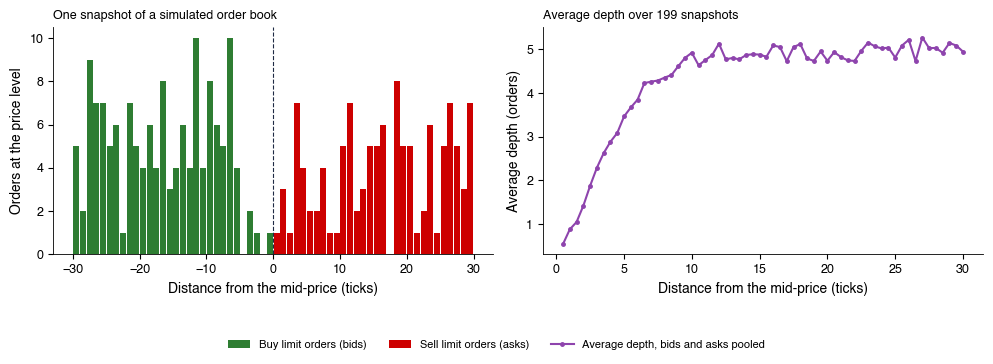

{'spread_mean': 3.2348333333333334, 'spread_med': 3.0, 'spread_p90': 6.0, 'n_snaps': 199, 'depth1': 0.824147114347357, 'depth10': 4.787874190938511, 'depth25': 4.979571197411003}


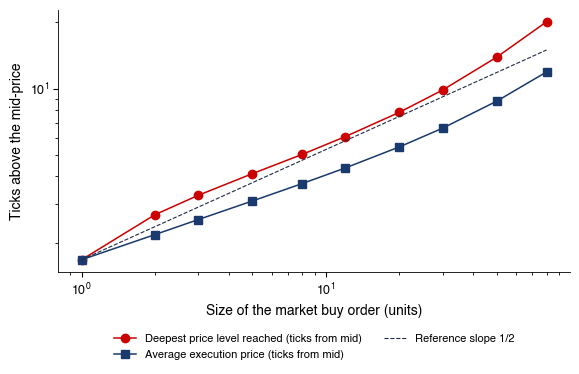

{'slope': 0.5321358775033925,
 'imp1': 1.6758793969849246,
 'imp80': 20.128140703517587,
 'cost1': 1.6758793969849246,
 'cost80': 11.918404522613065,
 'impslope_cost': 0.4355644158136949}

In [5]:
ZI_PARAMS = {'n_events': 300000, 'L': 40, 'rate_limit': 0.1, 'rate_market': 0.5, 'rate_cancel': 0.02, 'seed': 7}


def zi_book():
    """Simulate the order book and the impact function of a market order."""
    path, snaps, _ = zi_simulate(**ZI_PARAMS)
    prof = pd.concat(snaps).groupby('rel')[['bid', 'ask']].mean()
    sizes = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80]
    imp, cost = {}, {}
    for q in sizes:
        last, vw = [], []
        for s in snaps:
            a = s[(s['rel'] > 0) & (s['ask'] > 0)]
            asks = list(zip(a['rel'], a['ask']))
            if sum(x for _, x in asks) < q:
                continue
            fills, vwap, _, _ = walk_book(asks, q)
            last.append(max(p for p, _ in fills))
            vw.append(vwap)
        imp[q], cost[q] = np.mean(last), np.mean(vw)
    slope = np.polyfit(np.log(sizes), np.log([imp[q] for q in sizes]), 1)[0]
    return dict(path=path, snaps=snaps, prof=prof, sizes=sizes, imp=imp, cost=cost, slope=slope)


def pooled_profile(p):
    """Mean depth at distance k from the mid: average of bid(-k) and ask(+k) (the book is symmetric on average)."""
    ask = p['ask'][p.index > 0]
    bid = p['bid'][p.index < 0]
    bid.index = -bid.index
    return ((ask + bid.reindex(ask.index)) / 2).dropna()


def fig_lob(zb):
    snap = zb['snaps'][len(zb['snaps']) // 2]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    ax = axes[0]
    ax.bar(snap['rel'], snap['bid'], width=0.9, color=Forest, label='Buy limit orders (bids)')
    ax.bar(snap['rel'], snap['ask'], width=0.9, color=IDAred, label='Sell limit orders (asks)')
    ax.axvline(0, color=Gray, lw=0.8, ls='--')
    ax.set_xlabel('Distance from the mid-price (ticks)')
    ax.set_ylabel('Orders at the price level')
    ax.set_title('One snapshot of a simulated order book', fontsize=9, loc='left')
    ax = axes[1]
    p = zb['prof']
    pool = pooled_profile(p)
    ax.plot(pool.index, pool.values, color=Purple, lw=1.5, marker='o', ms=2.5, label='Average depth, bids and asks pooled')
    ax.set_xlabel('Distance from the mid-price (ticks)')
    ax.set_ylabel('Average depth (orders)')
    ax.set_title(f"Average depth over {len(zb['snaps'])} snapshots", fontsize=9, loc='left')
    h, l = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h + h2, l + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_lob_snapshot')
    sp = zb['path']['spread']
    return dict(spread_mean=float(sp.mean()), spread_med=float(sp.median()), spread_p90=float(sp.quantile(0.9)),
                n_snaps=len(zb['snaps']), depth1=float(pool.loc[0.5:1.5].mean()),
                depth10=float(pool.loc[9.5:10.5].mean()), depth25=float(pool.loc[24.5:25.5].mean()))


def fig_impact(zb):
    s = np.array(zb['sizes'])
    last = np.array([zb['imp'][q] for q in s])
    cost = np.array([zb['cost'][q] for q in s])
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    ax.loglog(s, last, 'o-', color=IDAred, label='Deepest price level reached (ticks from mid)')
    ax.loglog(s, cost, 's-', color=MainBlue, label='Average execution price (ticks from mid)')
    c = last[0] / s[0] ** 0.5
    ax.loglog(s, c * s ** 0.5, ls='--', color=Gray, lw=0.8, label='Reference slope 1/2')
    ax.set_xlabel('Size of the market buy order (units)')
    ax.set_ylabel('Ticks above the mid-price')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch10_walk_book')
    return dict(slope=float(zb['slope']), imp1=float(last[0]), imp80=float(last[-1]), cost1=float(cost[0]),
                cost80=float(cost[-1]), impslope_cost=float(np.polyfit(np.log(s), np.log(cost), 1)[0]))


zb = zi_book()
print(fig_lob(zb))
fig_impact(zb)

## 2. The Roll model (simulated)

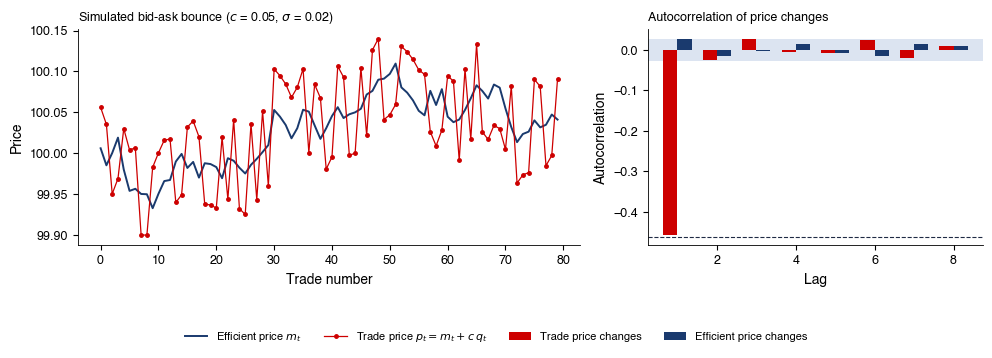

{'c': 0.05,
 'sigma': 0.02,
 'cov1': np.float64(-0.0024912833254543167),
 's_hat': np.float64(0.09982551428275872),
 's_true': 0.1,
 'var_dp': 0.00544197433993032,
 'var_theory': 0.005400000000000001,
 'rho1': -0.4577903477373279,
 'rho1_theory': -0.46296296296296297,
 'rho1_hat': -0.4577048396246077}

In [6]:
def roll_sim(n=5000, sigma=0.02, c=0.05, seed=SEED):
    """Efficient price m_t (random walk) and trade price p_t = m_t + c q_t, q_t = +1 / -1 (buy / sell)."""
    rng = np.random.default_rng(seed)
    m = 100 + np.cumsum(rng.normal(0, sigma, n))
    q = np.where(rng.random(n) < 0.5, 1, -1)
    p = m + c * q
    dp = np.diff(p)
    cov1 = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return m, q, p, dict(c=c, sigma=sigma, cov1=cov1, s_hat=2 * np.sqrt(-cov1), s_true=2 * c,
                         var_dp=float(np.var(dp)), var_theory=sigma ** 2 + 2 * c ** 2,
                         rho1=float(cov1 / np.var(dp)), rho1_theory=-c ** 2 / (sigma ** 2 + 2 * c ** 2))


def fig_roll():
    m, q, p, out = roll_sim()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3), gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    k = np.arange(80)
    ax.plot(k, m[:80], color=MainBlue, lw=1.4, label='Efficient price $m_t$')
    ax.plot(k, p[:80], color=IDAred, lw=0.9, marker='o', ms=2.5, label='Trade price $p_t = m_t + c\\,q_t$')
    ax.set_xlabel('Trade number')
    ax.set_ylabel('Price')
    ax.set_title('Simulated bid-ask bounce ($c$ = 0.05, $\\sigma$ = 0.02)', fontsize=9, loc='left')
    ax = axes[1]
    dp = np.diff(p)
    dm = np.diff(m)
    lags = np.arange(1, 9)
    acf_p = [np.corrcoef(dp[l:], dp[:-l])[0, 1] for l in lags]
    acf_m = [np.corrcoef(dm[l:], dm[:-l])[0, 1] for l in lags]
    ax.bar(lags - 0.18, acf_p, 0.36, color=IDAred, label='Trade price changes')
    ax.bar(lags + 0.18, acf_m, 0.36, color=MainBlue, label='Efficient price changes')
    b = 1.96 / np.sqrt(len(dp))
    ax.axhspan(-b, b, color=BandBlue, alpha=0.6, lw=0, zorder=0)
    ax.axhline(out['rho1_theory'], color=Gray, ls='--', lw=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation of price changes', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=4, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_roll_bounce')
    out['rho1_hat'] = float(acf_p[0])
    return out


fig_roll()

## 3. Intraday patterns of SPY and Bitcoin

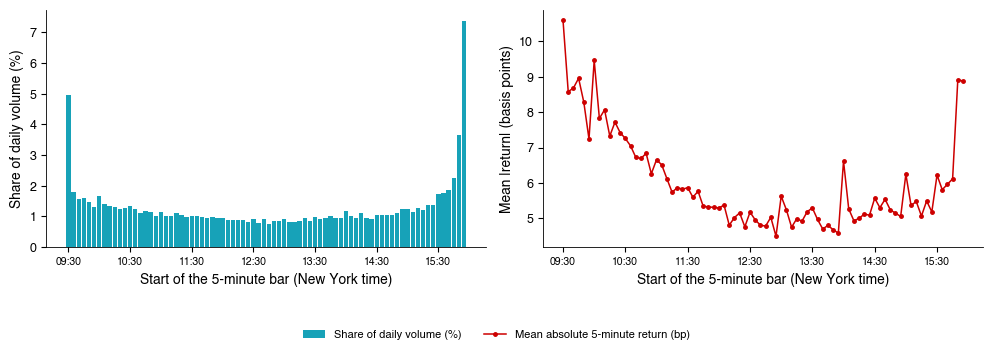

{'n_days': 1477,
 'first': '2020-10-12',
 'last': '2026-09-18',
 'share_open': 4.960268002147785,
 'share_close': 7.374423796775356,
 'share_last30': 18.630783223573474,
 'share_first30': 12.692625141838352,
 'share_mid': 0.909485230945039,
 'absr_open': 10.590414985574782,
 'absr_mid': 5.139410406383602,
 'absr_close': 8.879817050739323,
 'ratio_open_mid': 2.0606283888946777}

In [7]:
def spy_tod(s):
    """Profile by 5-minute interval: mean |r| (bp), median volume (million shares), share of the day's volume."""
    x = s.dropna(subset=['r'])
    tod = x.groupby('tod').agg(absr=('r', lambda v: 1e4 * v.abs().mean()), vol=('volume', 'median'))
    share = (s['volume'] / s.groupby('date')['volume'].transform('sum')).groupby(s['tod']).mean()
    tod['share'] = 100 * share
    return tod


def fig_spy_intraday(s):
    tod = spy_tod(s)
    x = np.arange(len(tod))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    ax.bar(x, tod['share'], color=Teal, width=0.85, label='Share of daily volume (%)')
    ax.set_ylabel('Share of daily volume (%)')
    ax = axes[1]
    ax.plot(x, tod['absr'], color=IDAred, marker='o', ms=2.5, label='Mean absolute 5-minute return (bp)')
    ax.set_ylabel('Mean |return| (basis points)')
    for a in axes:
        a.set_xticks(x[::12])
        a.set_xticklabels(tod.index[::12], rotation=0, fontsize=7.5)
        a.set_xlabel('Start of the 5-minute bar (New York time)')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_spy_intraday')
    mid = tod.loc['11:30':'14:00']
    return dict(n_days=int(s['date'].nunique()), first=s['date'].min().strftime('%Y-%m-%d'),
                last=s['date'].max().strftime('%Y-%m-%d'),
                share_open=float(tod['share'].iloc[0]), share_close=float(tod['share'].iloc[-1]),
                share_last30=float(tod['share'].iloc[-6:].sum()), share_first30=float(tod['share'].iloc[:6].sum()),
                share_mid=float(mid['share'].mean()), absr_open=float(tod['absr'].iloc[0]),
                absr_mid=float(mid['absr'].mean()), absr_close=float(tod['absr'].iloc[-1]),
                ratio_open_mid=float(tod['absr'].iloc[0] / mid['absr'].mean()))


spy = intraday_spy()
fig_spy_intraday(spy)

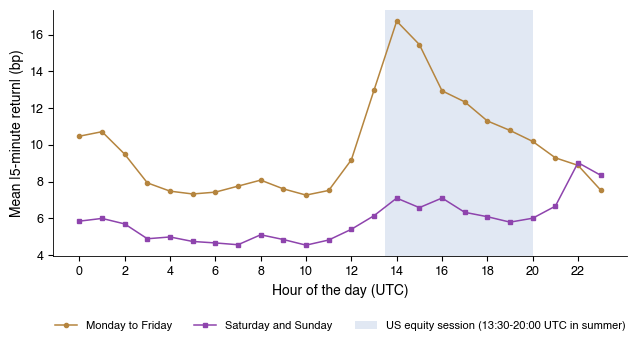

{'first': '2024-08-31',
 'last': '2026-09-18',
 'n_bars': 208596,
 'peak_hour': 14,
 'peak': 16.740055045021304,
 'low_hour': 10,
 'low': 7.270158900346827,
 'wd': 9.89904411876063,
 'we': 5.872959562630139,
 'ratio': 1.6855290783455443}

In [8]:
def btc_hours(b):
    x = b.dropna(subset=['r'])
    wk = x.index.dayofweek >= 5
    h = pd.DataFrame({'weekday': 1e4 * x.loc[~wk, 'r'].abs().groupby(x.index[~wk].hour).mean(),
                      'weekend': 1e4 * x.loc[wk, 'r'].abs().groupby(x.index[wk].hour).mean()})
    return h


def fig_btc_hours(b):
    h = btc_hours(b)
    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    ax.plot(h.index, h['weekday'], color=Amber, marker='o', ms=3, label='Monday to Friday')
    ax.plot(h.index, h['weekend'], color=Purple, marker='s', ms=3, label='Saturday and Sunday')
    ax.axvspan(13.5, 20, color=BandBlue, alpha=0.5, lw=0, label='US equity session (13:30-20:00 UTC in summer)')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('Hour of the day (UTC)')
    ax.set_ylabel('Mean |5-minute return| (bp)')
    legend_outside_bottom(ax, ncol=3, y=-0.22)
    save_fig('ch10_btc_hours')
    x = b.dropna(subset=['r'])
    wk = x.index.dayofweek >= 5
    return dict(first=b.index.min().strftime('%Y-%m-%d'), last=b.index.max().strftime('%Y-%m-%d'),
                n_bars=int(len(x)), peak_hour=int(h['weekday'].idxmax()), peak=float(h['weekday'].max()),
                low_hour=int(h['weekday'].idxmin()), low=float(h['weekday'].min()),
                wd=float(1e4 * x.loc[~wk, 'r'].abs().mean()), we=float(1e4 * x.loc[wk, 'r'].abs().mean()),
                ratio=float(x.loc[~wk, 'r'].abs().mean() / x.loc[wk, 'r'].abs().mean()))


btc = intraday_btc()
fig_btc_hours(btc)

## 4. Spread estimators at two frequencies and across 25 assets

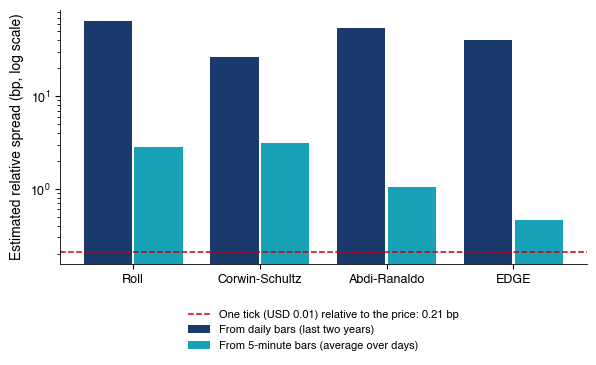

{'tick': 0.2065684865019977, 'roll5': 2.8178694948515814, 'cs5': 3.114235796578178, 'ar5': 1.0597709930490853, 'roll_d': 64.2538319726807, 'cs_d': 26.531990252599034, 'ar_d': 55.09545779283073, 'edge5': 0.45773126402100783, 'edge_d': 40.094405062870926, 'edge5_lo': 0.4206579364000719, 'edge5_hi': 0.49074631183619444, 'share_negcov': 0.5924170616113744, 'n_days': 1477}


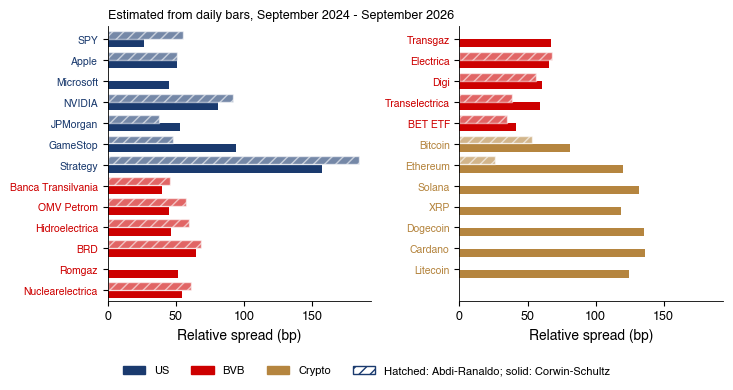

,roll,roll_cov,cs,edge,ar,ar_neg,n
SPY,64.253832,-0.00001,26.53199,40.094405,55.095458,False,501
AAPL,NaN,0.000013,50.589512,58.897625,51.054553,False,501
MSFT,NaN,0.000015,45.045298,-7.769576,0.0,True,501
NVDA,167.191409,-0.00007,81.123887,72.789731,91.977793,False,501
JPM,51.4506,-0.000007,53.105875,32.137955,37.814305,False,501
GME,109.139114,-0.00003,94.005731,17.89664,47.989338,False,501
MSTR,337.121177,-0.000284,157.131822,159.333039,184.272199,False,501
TLV,5.446375,-0.0,40.089851,32.632325,45.862954,False,493
SNP,35.188783,-0.000003,44.654538,54.639335,57.545941,False,493
H2O,NaN,0.000004,46.652379,53.085013,59.553925,False,493


In [9]:
def intraday_spreads(s):
    """Roll, Corwin-Schultz and Abdi-Ranaldo estimators computed on the 5-minute bars of each day."""
    rows = {}
    for d, g in s.dropna(subset=['close', 'high', 'low']).groupby('date'):
        rs, cov = roll_spread(g['close'])
        rows[d] = dict(cov=cov, cs=cs_spread(g['high'], g['low']).mean(),          # within the session: no overnight adjustment
                      
                       ar2=ar_terms(g['close'], g['high'], g['low']).mean(), price=g['close'].mean(),
                       edge=edge_spread(g['open'], g['high'], g['low'], g['close']),
                       var=np.var(np.diff(np.log(g['close'].values)), ddof=1))
    return pd.DataFrame(rows).T


def daily_spreads(key, start=START2):
    """Estimators from daily data over the last two years (values in basis points)."""
    d = ohlc(key, start)
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'], d['close'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return dict(roll=1e4 * rs if rs == rs else np.nan, roll_cov=float(cov), cs=1e4 * float(np.mean(cs)),
                edge=1e4 * edge_spread(d['open'], d['high'], d['low'], d['close']),
                ar=1e4 * float(np.sqrt(max(np.mean(ar2), 0))), ar_neg=bool(np.mean(ar2) <= 0), n=int(len(d)))


def spread_table():
    return {k: daily_spreads(k) for k in ASSETS}


def fig_spread_frequency(E, sp_daily):
    tick = 1e4 * (0.01 / E['price']).mean()
    roll5 = 1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0))
    cs5 = 1e4 * E['cs'].mean()
    ar5 = 1e4 * np.sqrt(max(E['ar2'].mean(), 0))
    edge5 = 1e4 * E['edge'].clip(lower=0).mean()     # negative window estimates set to zero before averaging (authors' recommendation)
    vals = {'Roll': (sp_daily['roll'], roll5), 'Corwin-Schultz': (sp_daily['cs'], cs5), 'Abdi-Ranaldo': (sp_daily['ar'], ar5),
            'EDGE': (sp_daily['edge'], edge5)}
    fig, ax = plt.subplots(figsize=(6.8, 3.3))
    x = np.arange(4)
    ax.bar(x - 0.2, [v[0] for v in vals.values()], 0.38, color=MainBlue, label='From daily bars (last two years)')
    ax.bar(x + 0.2, [v[1] for v in vals.values()], 0.38, color=Teal, label='From 5-minute bars (average over days)')
    ax.axhline(tick, color=IDAred, ls='--', lw=1.1, label=f'One tick (USD 0.01) relative to the price: {tick:.2f} bp')
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(list(vals))
    ax.set_ylabel('Estimated relative spread (bp, log scale)')
    legend_outside_bottom(ax, ncol=1, y=-0.14)
    save_fig('ch10_spread_frequency')
    rng = np.random.default_rng(SEED)
    ev = E['edge'].clip(lower=0).values
    eb = [1e4 * ev[rng.integers(0, len(ev), len(ev))].mean() for _ in range(B_BOOT)]
    return dict(tick=float(tick), roll5=float(roll5), cs5=float(cs5), ar5=float(ar5), roll_d=float(sp_daily['roll']),
                cs_d=float(sp_daily['cs']), ar_d=float(sp_daily['ar']), edge5=float(edge5), edge_d=float(sp_daily['edge']),
                edge5_lo=float(np.percentile(eb, 2.5)), edge5_hi=float(np.percentile(eb, 97.5)),
                share_negcov=float((E['cov'] < 0).mean()), n_days=int(len(E)))


def fig_spread_cross(T):
    """Corwin-Schultz and Abdi-Ranaldo spreads, 25 assets in two panels (13 + 12) so that the names stay legible."""
    keys = [k for g in ('US', 'BVB', 'Crypto') for k in GROUPS[g]]
    parts = [keys[:13], keys[13:]]
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6), sharex=True)
    for ax, ks in zip(axes, parts):
        y = np.arange(len(ks))
        ax.barh(y + 0.2, [T[k]['cs'] for k in ks], 0.38, color=[GROUP_COL[ASSETS[k][2]] for k in ks],
                label='Corwin-Schultz')
        ax.barh(y - 0.2, [T[k]['ar'] for k in ks], 0.38, color=[GROUP_COL[ASSETS[k][2]] for k in ks], alpha=0.6,
                hatch='///', edgecolor='white', label='Abdi-Ranaldo')
        ax.set_yticks(y)
        ax.set_yticklabels([LABELS[k] for k in ks], fontsize=7.5)
        for t, k in zip(ax.get_yticklabels(), ks):
            t.set_color(GROUP_COL[ASSETS[k][2]])
        ax.set_ylim(len(parts[0]) - 0.5, -0.6)
        ax.set_xlabel('Relative spread (bp)')
    axes[0].set_title('Estimated from daily bars, September 2024 - September 2026', fontsize=9, loc='left')
    from matplotlib.patches import Patch
    h = [Patch(color=MainBlue, label='US'), Patch(color=IDAred, label='BVB'), Patch(color=Amber, label='Crypto'),
         Patch(facecolor='white', edgecolor=MainBlue, hatch='///', label='Hatched: Abdi-Ranaldo; solid: Corwin-Schultz')]
    plt.tight_layout()
    fig.legend(handles=h, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=4, frameon=False)
    save_fig('ch10_spread_estimators')


E = intraday_spreads(spy)
T = spread_table()
print(fig_spread_frequency(E, T['SPY']))
fig_spread_cross(T)
pd.DataFrame(T).T.round(1)

### Small-sample properties of the Roll estimator (Harris, 1990)

- Share of days with a positive covariance and the Roll estimate from the autocovariance averaged over all days, observed and simulated under the Roll model.

In [10]:
def roll_small_sample(E):
    """Daily Roll covariance (77 five-minute returns): share of days with a positive covariance, observed and
    simulated under the true Roll model (one-tick spread; no spread), and the bias from subtracting the sample mean."""
    n = 77
    v = E['var'].mean()
    c_tick = (0.01 / E['price']).mean() / 2
    out = dict(pos_obs=float((E['cov'] > 0).mean()), n_days=int(len(E)), sd_bar=float(1e4 * np.sqrt(v)),
               c_tick=float(1e4 * c_tick))
    for tag, c in [('tick', c_tick), ('zero', 0.0)]:
        sig = np.sqrt(v - 2 * c ** 2)
        cov = np.array([roll_mc(c, sig, T=n + 1, R=len(E), seed=SEED + b) for b in range(200)])
        pos = (cov > 0).mean(axis=1)                        # 200 "samples" of the length of the real sample
        pooled = 1e4 * 2 * np.sqrt(np.clip(-cov.mean(axis=1), 0, None))
        out[f'pos_{tag}'] = float(pos.mean())
        out[f'pos_{tag}_lo'], out[f'pos_{tag}_hi'] = (float(x) for x in np.percentile(pos, [2.5, 97.5]))
        out[f'roll_{tag}'] = float(pooled.mean())
        out[f'roll_{tag}_lo'], out[f'roll_{tag}_hi'] = (float(x) for x in np.percentile(pooled, [2.5, 97.5]))
    # bias correction: E[cov_hat] ~ g1 - (g0 + 2 g1) / n  =>  g1 ~ (mean_cov + mean_var / n) / (1 - 2 / n)
    g1 = (E['cov'].mean() + v / n) / (1 - 2 / n)
    out['roll_corr'] = float(1e4 * 2 * np.sqrt(max(-g1, 0)))
    out['roll5'] = float(1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0)))
    return out


roll_small_sample(E)

{'pos_obs': 0.4075829383886256,
 'n_days': 1477,
 'sd_bar': 9.1583127862955,
 'c_tick': 0.10328424325099884,
 'pos_tick': 0.45316181448882875,
 'pos_tick_lo': 0.4299255247122546,
 'pos_tick_hi': 0.4808395396073122,
 'roll_tick': 2.0730377581893937,
 'roll_tick_lo': 1.5056679955636603,
 'roll_tick_hi': 2.53365546070691,
 'pos_zero': 0.4533243060257279,
 'pos_zero_lo': 0.4312796208530806,
 'pos_zero_hi': 0.4828199052132701,
 'roll_zero': 2.0625393126665523,
 'roll_zero_lo': 1.4988282803065303,
 'roll_zero_hi': 2.526258631145369,
 'roll_corr': 1.9180237793613462,
 'roll5': 2.8178694948515814}

## 5. Amihud illiquidity: cross-section and time series

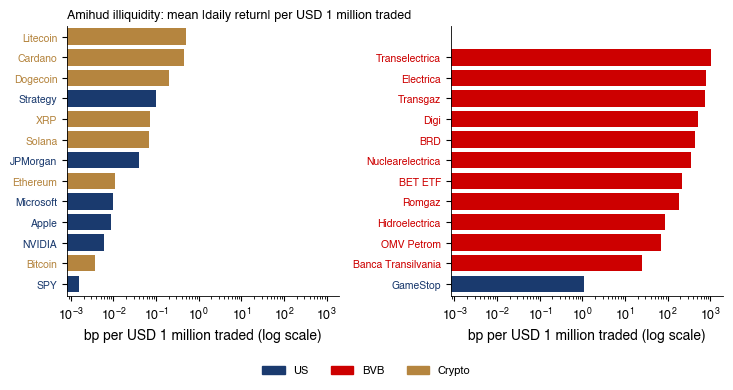

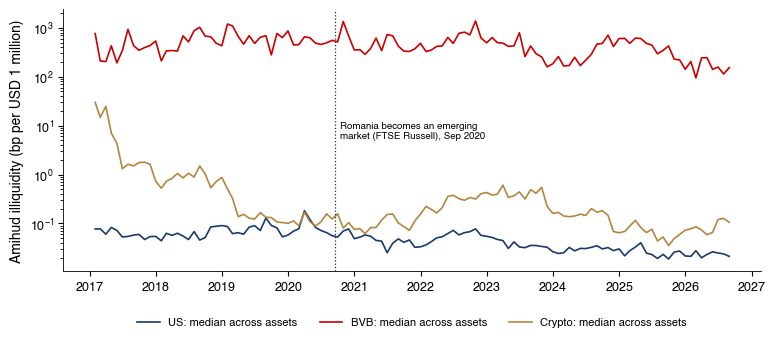

{'bvb_2017': 435.18275485986527, 'bvb_2026': 169.4213377540072, 'us_2017': 0.06236517942658145, 'us_2026': 0.02349180683278598, 'cr_2017': 7.604647281292688, 'cr_2026': 0.08915578655197696, 'ratio_bvb_us_2026': 7211.933035204295}


,illiq,dv_med,n
SPY,0.0016,40124.2235,500.0
AAPL,0.0088,11464.8278,500.0
MSFT,0.0097,10505.4882,500.0
NVDA,0.0060,30026.4606,500.0
JPM,0.0402,2360.7741,500.0
GME,1.1200,149.5000,500.0
MSTR,0.1003,3756.4297,500.0
TLV,24.7334,3.8998,492.0
SNP,68.3754,1.5246,492.0
H2O,88.5493,1.0588,492.0


In [11]:
def amihud_table(start=START2):
    out = {}
    for k in ASSETS:
        r = returns(k, start)
        dv = dollar_volume(k, start)
        out[k] = dict(illiq=amihud(r, dv), dv_med=float(dv.median() / 1e6), n=int(len(r)))
    return out


def fig_amihud(A):
    """Amihud illiquidity of the 25 assets, sorted, in two panels (13 + 12) so that the names stay legible."""
    keys = sorted(ASSETS, key=lambda k: A[k]['illiq'])
    parts = [keys[:13], keys[13:]]
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6), sharex=True)
    for ax, ks in zip(axes, parts):
        y = np.arange(len(ks))
        ax.barh(y, [A[k]['illiq'] for k in ks], color=[GROUP_COL[ASSETS[k][2]] for k in ks])
        ax.set_xscale('log')
        ax.set_yticks(y)
        ax.set_yticklabels([LABELS[k] for k in ks], fontsize=7.5)
        for t, k in zip(ax.get_yticklabels(), ks):
            t.set_color(GROUP_COL[ASSETS[k][2]])
        ax.set_ylim(-0.6, len(parts[0]) - 0.5)
        ax.set_xlabel('bp per USD 1 million traded (log scale)')
    axes[0].set_title('Amihud illiquidity: mean |daily return| per USD 1 million traded', fontsize=9, loc='left')
    from matplotlib.patches import Patch
    plt.tight_layout()
    fig.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COL.items()], loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch10_amihud')


def monthly_illiq(keys, start=START10):
    """Monthly Amihud illiquidity (bp per USD 1 million) for each asset; median by group."""
    cols = {}
    for k in keys:
        x = pd.concat([returns(k, start).rename('r'), dollar_volume(k, start).rename('dv')], axis=1, join='inner').dropna()
        x = x[x['dv'] > 0]
        cols[k] = (1e4 * x['r'].abs() / (x['dv'] / 1e6)).resample('ME').mean()
    return pd.DataFrame(cols)


def fig_amihud_time():
    med = {}
    for g in ('US', 'BVB', 'Crypto'):
        keys = [k for k in GROUPS[g] if k not in ('SPY', 'TVBETETF')]
        med[g] = monthly_illiq(keys).median(axis=1)
    med = pd.DataFrame(med).loc['2017-01':'2026-08']
    fig, ax = plt.subplots(figsize=(9, 3.4))
    for g, c in GROUP_COL.items():
        ax.plot(med.index, med[g], color=c, lw=1.2, label=f'{g}: median across assets')
    ax.set_yscale('log')
    ax.set_ylabel('Amihud illiquidity (bp per USD 1 million)')
    ax.axvline(pd.Timestamp('2020-09-15'), color=Gray, ls=':', lw=0.9)
    ax.text(pd.Timestamp('2020-10-15'), 8, 'Romania becomes an emerging\nmarket (FTSE Russell), Sep 2020',
            fontsize=7, color='black', va='center')
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch10_amihud_time')
    r = med.resample('YE').mean()
    return dict(bvb_2017=float(r['BVB'].iloc[0]), bvb_2026=float(r['BVB'].iloc[-1]),
                us_2017=float(r['US'].iloc[0]), us_2026=float(r['US'].iloc[-1]),
                cr_2017=float(r['Crypto'].iloc[0]), cr_2026=float(r['Crypto'].iloc[-1]),
                ratio_bvb_us_2026=float(r['BVB'].iloc[-1] / r['US'].iloc[-1]))


A = amihud_table()
fig_amihud(A)
print(fig_amihud_time())
pd.DataFrame(A).T.round(4)

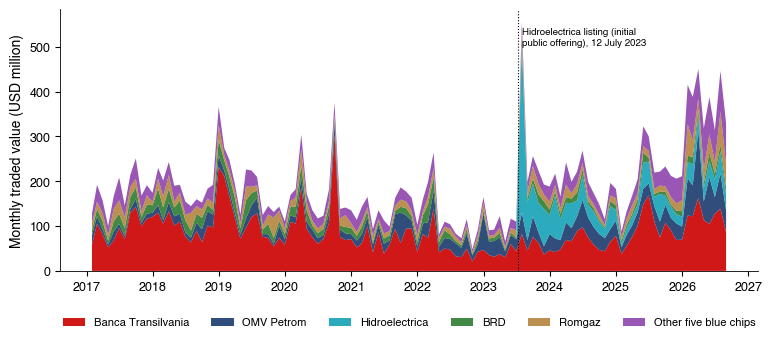

{'y2017': 2097.991873416029,
 'y2022': 1494.379079726255,
 'y2024': 2328.357395502786,
 'y2025': 2519.5879100678903,
 'tlv_share': 0.4405701086387218,
 'h2o_share': 0.13355825207990324}

In [12]:
def fig_bvb_turnover():
    keys = [k for k in GROUPS['BVB'] if k != 'TVBETETF']
    dv = pd.DataFrame({k: dollar_volume(k, START10) for k in keys}).fillna(0)
    m = dv.resample('ME').sum().loc['2017-01':'2026-08'] / 1e6
    top = ['TLV', 'SNP', 'H2O', 'BRD', 'SNG']
    fig, ax = plt.subplots(figsize=(9, 3.4))
    cols = [IDAred, MainBlue, Teal, Forest, Amber]
    ax.stackplot(m.index, [m[k] for k in top] + [m[[k for k in keys if k not in top]].sum(axis=1)],
                 colors=cols + [Purple], labels=[LABELS[k] for k in top] + ['Other five blue chips'], alpha=0.9)
    ax.set_ylabel('Monthly traded value (USD million)')
    ax.axvline(pd.Timestamp('2023-07-12'), color='black', lw=0.8, ls=':')
    ax.text(pd.Timestamp('2023-08-01'), ax.get_ylim()[1] * 0.93, 'Hidroelectrica listing (initial\npublic offering), 12 July 2023', fontsize=7, color='black', va='top')
    legend_outside_bottom(ax, ncol=6, y=-0.14)
    save_fig('ch10_bvb_turnover')
    y = m.sum(axis=1).resample('YE').sum()
    return dict(y2017=float(y.loc['2017'].iloc[0]), y2022=float(y.loc['2022'].iloc[0]), y2024=float(y.loc['2024'].iloc[0]),
                y2025=float(y.loc['2025'].iloc[0]), tlv_share=float(m['TLV'].loc['2025'].sum() / m.loc['2025'].sum().sum()),
                h2o_share=float(m['H2O'].loc['2025'].sum() / m.loc['2025'].sum().sum()))


fig_bvb_turnover()

### Price discovery: the BET ETF and the BET-TR index

- The Patria-TVBETETF (an exchange-traded fund, ETF, on the BET index) and the BET total-return index (BET-TR).
- VECM with the cointegrating vector (1, -1); Hasbrouck information-share bounds; Gonzalo–Granger component share.

In [13]:
PD_START = '2024-09-19'
END_PD = '2026-09-18'


def bet_etf_pair(start=PD_START):
    """Log closing prices: the Patria-TVBETETF (trading days) and the BET-TR index, common days."""
    e = read_market('TVBETETF.RO')
    e = e[e['volume'] > 0]
    idx = read_market('BETTR.INDX')
    j = pd.concat([e['close'].rename('etf'), idx['close'].rename('idx')], axis=1, join='inner').dropna().loc[start:END_PD]
    return np.log(j)


def price_discovery_bet():
    from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order
    y = bet_etf_pair()
    p = int(select_order(y.values, maxlags=10, deterministic='co').bic)
    jo = coint_johansen(y.values, 0, max(p, 1))
    r = price_discovery(y.values, max(p, 1))
    sd = float(100 * (y['etf'] - y['idx']).std())
    return dict(n=int(len(y)), p=max(p, 1), trace=float(jo.lr1[0]), cv=float(jo.cvt[0, 1]), trace1=float(jo.lr1[1]),
                cv1=float(jo.cvt[1, 1]), a_etf=float(r['alpha'][0]), a_idx=float(r['alpha'][1]), t_etf=float(r['t'][0]),
                t_idx=float(r['t'][1]), cs_etf=float(r['cs'][0]), cs_idx=float(r['cs'][1]), is_etf_lo=float(r['is_lo'][0]),
                is_etf_hi=float(r['is_hi'][0]), is_idx_lo=float(r['is_lo'][1]), is_idx_hi=float(r['is_hi'][1]),
                corr=r['corr'], sd_basis=sd, start=y.index[0].strftime('%Y-%m-%d'), end=y.index[-1].strftime('%Y-%m-%d'))


price_discovery_bet()

{'n': 495,
 'p': 1,
 'trace': 49.638335176116335,
 'cv': 15.4943,
 'trace1': 0.10180446807762619,
 'cv1': 3.8415,
 'a_etf': -0.1214459102853011,
 'a_idx': -0.03428253008476459,
 't_etf': -2.1099805086951555,
 't_idx': -0.6336008319602243,
 'cs_etf': -0.3933134534926351,
 'cs_idx': 1.393313453492635,
 'is_etf_lo': 0.022599987575940887,
 'is_etf_hi': 0.7493696794181902,
 'is_idx_lo': 0.2506303205818098,
 'is_idx_hi': 0.9774000124240595,
 'corr': 0.9310847008895238,
 'sd_basis': 0.842561262904749,
 'start': '2024-09-19',
 'end': '2026-09-18'}

## 6. Liquidity and volatility: SPY and the VIX

- VIX: the CBOE index of the 30-day implied volatility of the S&P 500.

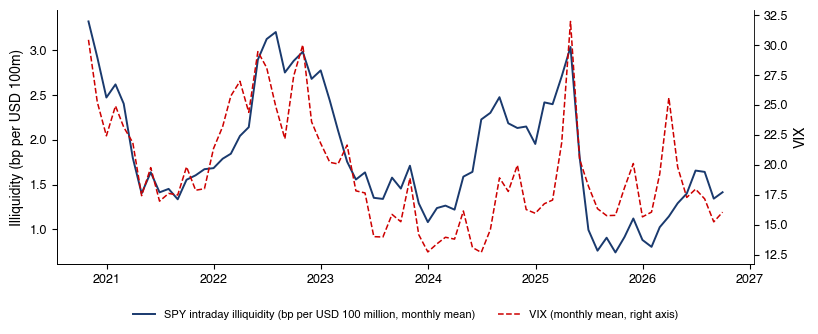

{'corr': 0.5849225297602763,
 'corr_m': 0.6902669158412825,
 'elast': 0.9544304059527832,
 'elast_se': 0.12116131927996482,
 'n': 1477,
 'mean': 1.8339556993864106,
 'y2020': 2.8588078413651576,
 'y2022': 2.598432009926328,
 'y2026': 1.3042643027859848,
 'apr2025': 3.0372145391281586}

In [14]:
def spy_illiq_daily(s):
    """Intraday illiquidity: mean |r_5min| (bp) per USD 100 million traded, by day."""
    x = s.dropna(subset=['r', 'dv'])
    x = x[x['dv'] > 0]
    return (1e4 * x['r'].abs() / (x['dv'] / 1e8)).groupby(x['date']).mean().rename('illiq')


def fig_illiq_vix(s):
    ill = spy_illiq_daily(s)
    vix = read_market('VIX.INDX')['close'].rename('vix')
    j = pd.concat([ill, vix], axis=1, join='inner').dropna()
    m = j.resample('ME').mean()
    fig, ax = plt.subplots(figsize=(9, 3.3))
    l1 = ax.plot(m.index, m['illiq'], color=MainBlue, lw=1.4, label='SPY intraday illiquidity (bp per USD 100 million, monthly mean)')
    ax.set_ylabel('Illiquidity (bp per USD 100m)')
    ax2 = ax.twinx()
    ax2.spines['right'].set_visible(True)
    l2 = ax2.plot(m.index, m['vix'], color=IDAred, lw=1.1, ls='--', label='VIX (monthly mean, right axis)')
    ax2.set_ylabel('VIX')
    ax.legend(l1 + l2, [l.get_label() for l in l1 + l2], loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2,
              frameon=False)
    save_fig('ch10_spy_illiq_vix')
    X = sm.add_constant(np.log(j['vix']))
    fit = sm.OLS(np.log(j['illiq']), X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    return dict(corr=float(j.corr().iloc[0, 1]), corr_m=float(m.corr().iloc[0, 1]), elast=float(fit.params.iloc[1]),
                elast_se=float(fit.bse.iloc[1]), n=int(len(j)), mean=float(j['illiq'].mean()),
                y2020=float(ill.loc['2020'].mean()), y2022=float(ill.loc['2022'].mean()),
                y2026=float(ill.loc['2026'].mean()), apr2025=float(ill.loc['2025-04'].mean()))


fig_illiq_vix(spy)

## 7. Glosten–Milgrom and Kyle

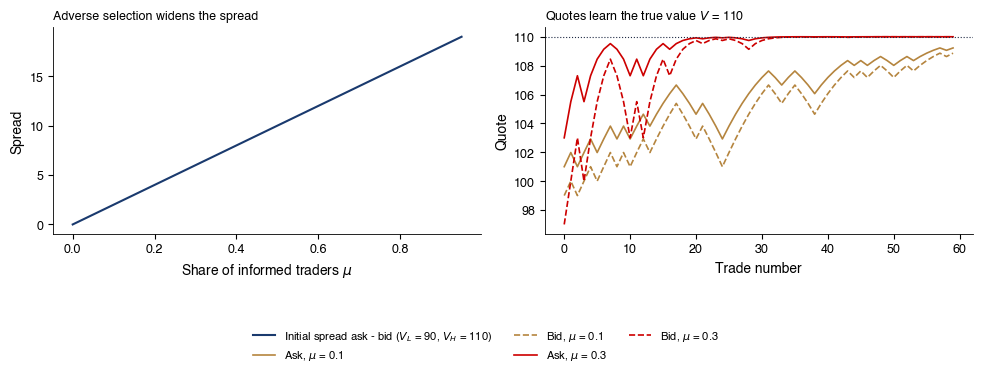

{'spread_01': 2.0, 'spread_03': 6.0, 't108_01': 48, 't108_03': 7}


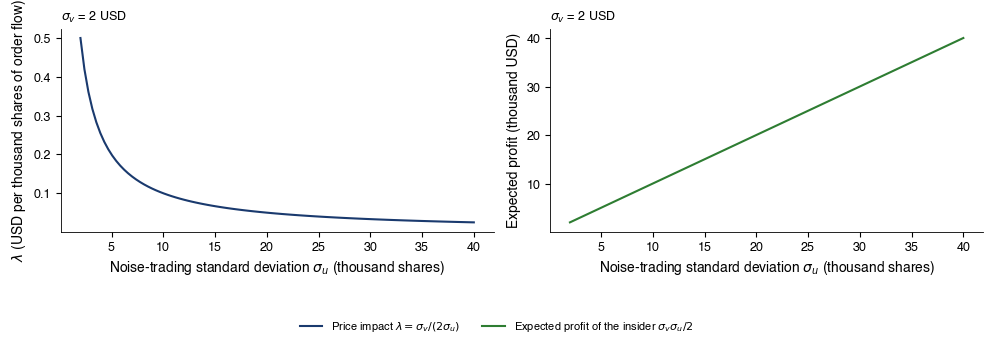

In [15]:
def fig_gm():
    mus = np.linspace(0, 0.95, 60)
    spreads = [gm_quotes(0.5, m, 90, 110)[0] - gm_quotes(0.5, m, 90, 110)[1] for m in mus]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    ax.plot(mus, spreads, color=MainBlue, lw=1.5, label='Initial spread ask - bid ($V_L$ = 90, $V_H$ = 110)')
    ax.set_xlabel('Share of informed traders $\\mu$')
    ax.set_ylabel('Spread')
    ax.set_title('Adverse selection widens the spread', fontsize=9, loc='left')
    ax = axes[1]
    sims = {}
    for mu, c in [(0.1, Amber), (0.3, IDAred)]:
        d = gm_simulate(mu, n=60, seed=3)
        sims[mu] = d
        ax.plot(d['t'], d['ask'], color=c, lw=1.2, label=f'Ask, $\\mu$ = {mu}')
        ax.plot(d['t'], d['bid'], color=c, lw=1.2, ls='--', label=f'Bid, $\\mu$ = {mu}')
    ax.axhline(110, color=Gray, lw=0.8, ls=':')
    ax.set_xlabel('Trade number')
    ax.set_ylabel('Quote')
    ax.set_title('Quotes learn the true value $V$ = 110', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_glosten_milgrom')
    first90 = {mu: int(next((i for i, r in d.iterrows() if r['bid'] > 108), -1)) for mu, d in sims.items()}
    return dict(spread_01=float(gm_quotes(0.5, 0.1, 90, 110)[0] - gm_quotes(0.5, 0.1, 90, 110)[1]),
                spread_03=float(gm_quotes(0.5, 0.3, 90, 110)[0] - gm_quotes(0.5, 0.3, 90, 110)[1]),
                t108_01=first90[0.1], t108_03=first90[0.3])


def fig_kyle():
    su = np.linspace(2, 40, 100)
    sv = 2.0
    lam = [kyle(sv, u)['lam'] for u in su]
    prof = [kyle(sv, u)['profit'] for u in su]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(su, lam, color=MainBlue, lw=1.5, label='Price impact $\\lambda = \\sigma_v / (2\\sigma_u)$')
    axes[0].set_xlabel('Noise-trading standard deviation $\\sigma_u$ (thousand shares)')
    axes[0].set_ylabel('$\\lambda$ (USD per thousand shares of order flow)')
    axes[1].plot(su, prof, color=Forest, lw=1.5, label='Expected profit of the insider $\\sigma_v \\sigma_u / 2$')
    axes[1].set_xlabel('Noise-trading standard deviation $\\sigma_u$ (thousand shares)')
    axes[1].set_ylabel('Expected profit (thousand USD)')
    for a in axes:
        a.set_title('$\\sigma_v$ = 2 USD', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_kyle')


print(fig_gm())
fig_kyle()

## 8. Volume and price moves; optimal execution

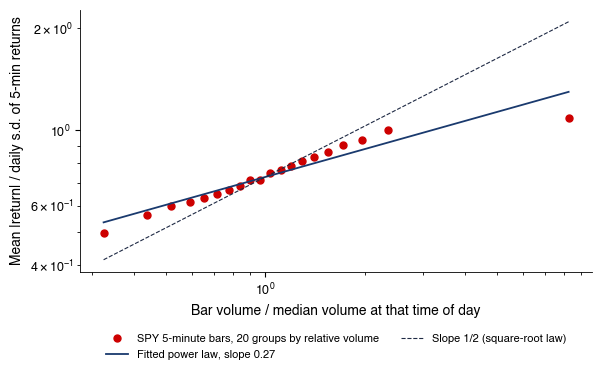

{'slope': 0.2741805378202134, 'n': 115052}

In [16]:
def sqrt_relation(s, nb=20):
    x = s.dropna(subset=['r', 'volume']).copy()
    x = x[x['volume'] > 0]
    x['part'] = x['volume'] / x.groupby('tod')['volume'].transform('median')
    x['z'] = x['r'].abs() / x.groupby('date')['r'].transform('std')
    bins = np.quantile(x['part'], np.linspace(0, 1, nb + 1))
    g = x.groupby(pd.cut(x['part'], bins, include_lowest=True)).agg(v=('part', 'mean'), z=('z', 'mean'))
    slope, icpt = np.polyfit(np.log(g['v']), np.log(g['z']), 1)
    return x, g, slope, icpt


def fig_sqrt(s):
    x, g, slope, icpt = sqrt_relation(s)
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    ax.loglog(g['v'], g['z'], 'o', color=IDAred, ms=5, label='SPY 5-minute bars, 20 groups by relative volume')
    vv = np.linspace(g['v'].min(), g['v'].max(), 50)
    ax.loglog(vv, np.exp(icpt) * vv ** slope, color=MainBlue, lw=1.3, label=f'Fitted power law, slope {slope:.2f}')
    ax.loglog(vv, np.exp(icpt) * vv ** 0.5, color=Gray, ls='--', lw=0.8, label='Slope 1/2 (square-root law)')
    ax.set_xlabel('Bar volume / median volume at that time of day')
    ax.set_ylabel('Mean |return| / daily s.d. of 5-min returns')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch10_sqrt_law')
    return dict(slope=float(slope), n=int(len(x)))


fig_sqrt(spy)

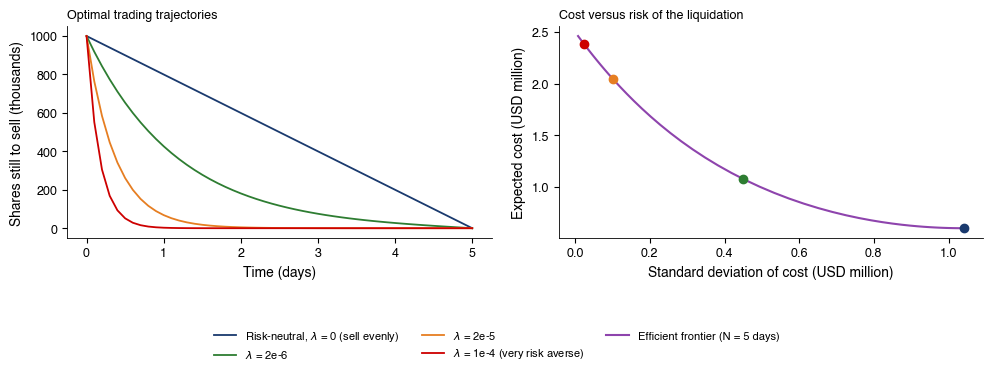

{'0': (600000, 1040673),
 '2e-06': (1078215, 449368),
 '2e-05': (2047390, 100616),
 '0.0001': (2384076, 23772)}

In [17]:
AC = {'X': 1000000.0, 'T': 5, 'N': 5, 'sigma': 0.95, 'eta': 2.5e-06, 'gamma': 2.5e-07}   # numerical example of Almgren and Chriss (2001)


def fig_ac():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    res = {}
    for lam, c, lab in [(0, MainBlue, 'Risk-neutral, $\\lambda$ = 0 (sell evenly)'), (2e-6, Forest, '$\\lambda$ = 2e-6'),
                        (2e-5, Orange, '$\\lambda$ = 2e-5'), (1e-4, IDAred, '$\\lambda$ = 1e-4 (very risk averse)')]:
        t, x, E, V = ac_trajectory(lam=lam, N=50, **{k: v for k, v in AC.items() if k != 'N'})
        ax.plot(t, x / 1e3, color=c, lw=1.3, label=lab)
        t5, x5, E5, V5 = ac_trajectory(lam=lam, **AC)
        res[lam] = dict(x=list(x5), E=E5, sd=np.sqrt(V5))
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Shares still to sell (thousands)')
    ax.set_title('Optimal trading trajectories', fontsize=9, loc='left')
    ax = axes[1]
    lams = np.logspace(-8, -3.5, 60)
    fr = ac_frontier(lams=lams, **AC)
    ax.plot(fr['sd'] / 1e6, fr['E'] / 1e6, color=Purple, lw=1.5, label='Efficient frontier (N = 5 days)')
    for lam, c in [(0, MainBlue), (2e-6, Forest), (2e-5, Orange), (1e-4, IDAred)]:
        ax.plot(res[lam]['sd'] / 1e6, res[lam]['E'] / 1e6, 'o', color=c, ms=6)
    ax.set_xlabel('Standard deviation of cost (USD million)')
    ax.set_ylabel('Expected cost (USD million)')
    ax.set_title('Cost versus risk of the liquidation', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_almgren_chriss')
    return {str(k): v for k, v in res.items()}


res = fig_ac()
{k: (round(v['E']), round(v['sd'])) for k, v in res.items()}

## 9. Stress episodes: 6 May 2010 and April 2025

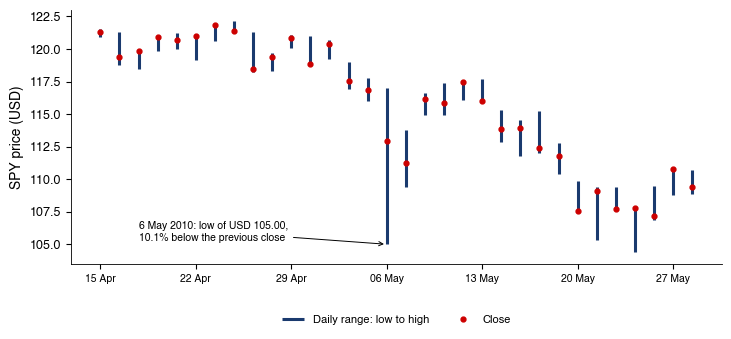

{'low': 105.0,
 'close': 112.942,
 'prev': 116.82,
 'drop_low': -0.10118130457113506,
 'drop_close': -0.03319637048450608,
 'vol_ratio': 2.970236287575119}

In [18]:
def fig_flash():
    d = read_market('SPY.US').loc['2010-04-15':'2010-05-28']
    prev = d['close'].shift(1)
    fig, ax = plt.subplots(figsize=(8.4, 3.3))
    x = np.arange(len(d))
    ax.vlines(x, d['low'], d['high'], color=MainBlue, lw=2.2, label='Daily range: low to high')
    ax.plot(x, d['close'], 'o', color=IDAred, ms=3.5, label='Close')
    i = d.index.get_loc(pd.Timestamp('2010-05-06'))
    ax.annotate('6 May 2010: low of USD 105.00,\n10.1% below the previous close', xy=(i, d['low'].iloc[i]),
                xytext=(i - 13, d['low'].iloc[i] + 0.3), fontsize=7.5, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))
    ax.set_xticks(x[::5])
    ax.set_xticklabels([t.strftime('%d %b') for t in d.index[::5]], fontsize=7.5)
    ax.set_ylabel('SPY price (USD)')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch10_flash_crash')
    r = d.loc['2010-05-06']
    return dict(low=float(r['low']), close=float(r['close']), prev=float(prev.loc['2010-05-06']),
                drop_low=float(r['low'] / prev.loc['2010-05-06'] - 1), drop_close=float(r['close'] / prev.loc['2010-05-06'] - 1),
                vol_ratio=float(r['volume'] / d['volume'].loc[:'2010-05-05'].median()))


fig_flash()

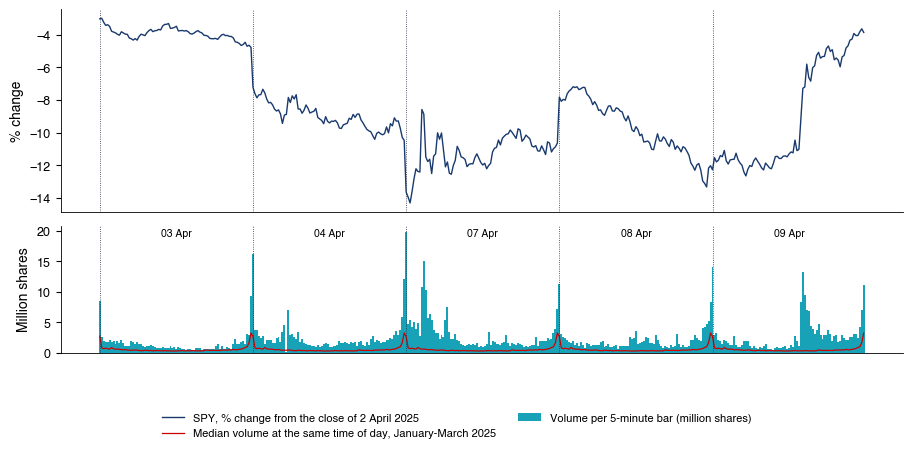

{'max_bar7': 4.276681403621829,
 'min_bar7': -2.9202520023476453,
 'range7': 8.586549629774076,
 'oc9': 10.011353720771087,
 'vol_ratio': 4.557156205161969,
 'rv7': 6.719062074797999,
 'rv_med': 0.6097448728318817}

In [19]:
def fig_april2025(s):
    days = ['2025-04-03', '2025-04-04', '2025-04-07', '2025-04-08', '2025-04-09']
    base = s.loc[s['date'] < pd.Timestamp(days[0])]
    prev_close = base['close'].dropna().iloc[-1]
    x = s.loc[s['date'].isin(pd.to_datetime(days))].copy()
    typical = s.loc['2025-01-01':'2025-03-31'].groupby('tod')['volume'].median()
    fig, axes = plt.subplots(2, 1, figsize=(9.2, 4.2), sharex=True, gridspec_kw={'height_ratios': [1.6, 1]})
    k = np.arange(len(x))
    axes[0].plot(k, 100 * (x['close'] / prev_close - 1), color=MainBlue, lw=1.0, label='SPY, % change from the close of 2 April 2025')
    axes[1].bar(k, x['volume'] / 1e6, color=Teal, width=1.0, label='Volume per 5-minute bar (million shares)')
    axes[1].plot(k, typical.reindex(x['tod']).values / 1e6, color=IDAred, lw=0.9,
                 label='Median volume at the same time of day, January-March 2025')
    for j, dd in enumerate(days):
        axes[1].text(78 * j + 39, axes[1].get_ylim()[1] * 0.92 if j == 0 else axes[1].get_ylim()[1] * 0.92,
                     pd.Timestamp(dd).strftime('%d %b'), ha='center', fontsize=7.5, color='black')
        for a in axes:
            a.axvline(78 * j, color=Gray, lw=0.6, ls=':')
    axes[0].set_ylabel('% change')
    axes[1].set_ylabel('Million shares')
    axes[1].set_xticks([])
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.03)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_april2025')
    d7 = s.loc[s['date'] == pd.Timestamp('2025-04-07')]
    d9 = s.loc[s['date'] == pd.Timestamp('2025-04-09')]
    rv = s.groupby('date')['r'].apply(lambda v: np.sqrt((v ** 2).sum()))
    return dict(max_bar7=float(100 * d7['r'].max()), min_bar7=float(100 * d7['r'].min()),
                range7=float(100 * (d7['high'].max() / d7['low'].min() - 1)),
                oc9=float(100 * (d9['close'].iloc[-1] / d9['open'].iloc[0] - 1)),
                vol_ratio=float(x['volume'].sum() / (typical.sum() * len(days))),
                rv7=float(100 * rv.loc['2025-04-07']), rv_med=float(100 * rv.median()))


fig_april2025(spy)